# 💻 **Evidencia 1**

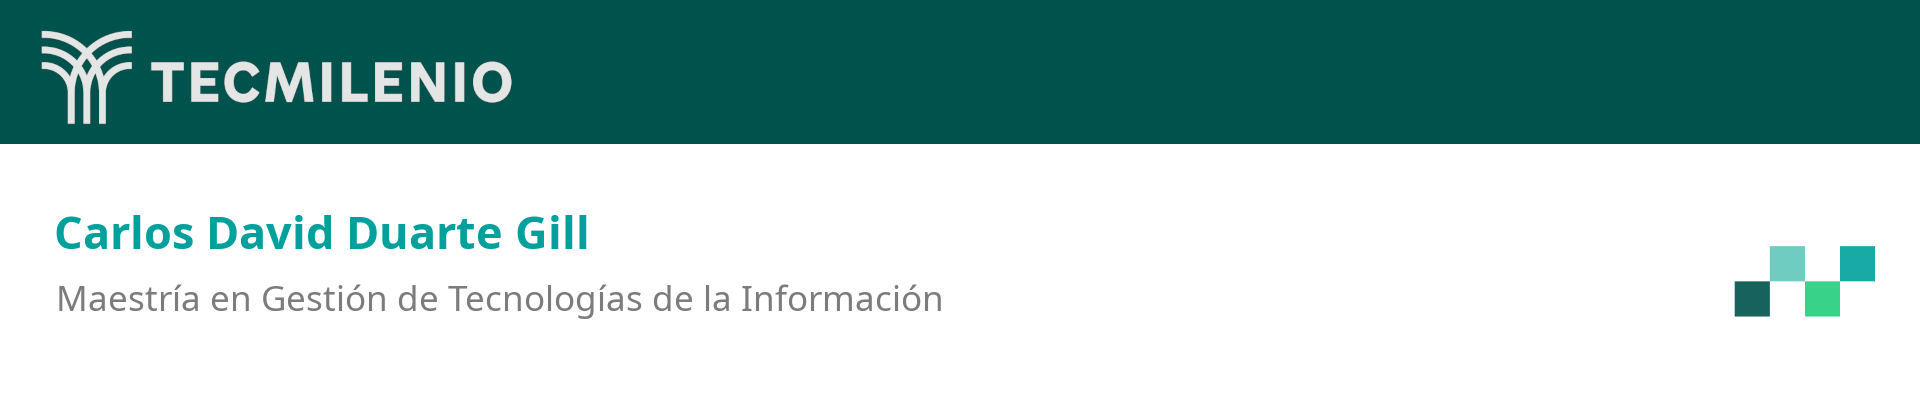

## **Aplicaciones avanzadas en ciencia de datos**

- Alumno: Carlos David Duarte Gill
- Matricula: 7089642
- Correo: AL07089642@tecmilenio.mx
- Profesor: Martín Antonio Santos Romero
- Fecha:  domingo 12 de abril de 2026

*Cursando la Maestría en Gestión de Tecnologías de la Información*

# 📘 Introducción a la Evidencia 1

La Evidencia 1 representa la suma de los esfuerzos dedicados al caso de NovaCredit Solutions tras haber explorado, limpiado y modelado los datos históricos de la cartera de clientes en las actividades previas. 
En esta primer evidencia se inicia con la transición de un análisis exploratorio fijo hacia la construcción de un Pipeline de Ciencia de Datos estructurado que nos permita integrar la predicción del riesgo de default en un flujo de trabajo gestionado bajo las bases de MLOps necesarias para que estos modelos generen valor continuo y automatizado en la toma de decisiones de la empresa.

## 🗽 Alcance de la Evidencia 1

En esta evidencia se logrará simular un entorno real de producción integrando el ciclo de vida del modelo predictivo. Para ello se incluirá:

- Estandarización de datos y tratamiento de desbalanceo nativo.

- Entrenamiento y optimización de hiperparámetros de modelos de ensamble como Random Forest para detectar morosidad temprana.

- Segmentación de clientes mediante K-Means y detección de anomalías con Isolation Forest para personalizar estrategias de cobranza y riesgo.

- Implementación de prácticas de rastreo de experimentos y control de versiones de modelos utilizando herramientas de la industria para garantizar auditoría y escalabilidad.

# 📖 Definición del problema analítico

## 📝 Contexto

El análisis histórico de NovaCredit Solutions ha revelado una tasa de morosidad alarmante que alcanza el 75.8% de la cartera de clientes lo que ocasiona que la empresa se enfrente a una crisis de rentabilidad. Dado este escenario, el problema de negocio radica en que la organización opera bajo un enfoque reactivo para la gestión del crédito, las políticas de captación y mantenimiento de líneas de crédito actuales no logran identificar oportunamente comportamientos morosos, permitiendo que perfiles de alto riesgo acaben con el capital de la empresa.

## 🏁 Objetivo analítico

El objetivo practico es diseñar, entrenar y desplegar un modelo predictivo de aprendizaje automático capaz de calcular la probabilidad individual de que un cliente incumpla con sus obligaciones crediticias, basándose en su perfil demográfico y comportamiento transaccional histórico. Este modelo actuará como un filtro automatizado para la toma de decisiones de la empresa.

La predicción se centrará en la variable objetivo **default_12m**.

## 🧭 Valor esperado de la solución

La implementación de este pipeline analítico y su despliegue operativo generará un impacto transformacional en tres frentes clave para NovaCredit:

- Reducción de pérdidas al predecir el riesgo con alta precisión la empresa podrá implementar políticas de congelamiento de líneas de crédito de forma automatizada, previniendo la fuga de capital.

- La rentabilidad comercial aumentará gracias a la segmentación de los clientes, el equipo de marketing podrá enfocar sus presupuestos de retención exclusivamente en los segmentos de bajo riesgo, maximizando el valor del ciclo de vida del cliente.

- La integración de MLOps permitirá mantener un modelo de decisiones en tiempo real, auditable y escalable para el futuro crecimiento de la empresa.

# 💻 Entorno Python para la Evidencia 1

Para garantizar la compatibilidad del código y su correcta ejecución, el proyecto fue desarrollado bajo un entorno virtual gestionado con Conda y    configurado con Python 3.10, en el entorno de desarrollo se incluyen herramientas tales como:

- Entorno de Desarrollo interactivo con *jupyter* para el desarrollo ágil y documentación eficiente.

- *pandas* para el procesamiento en memoria de la estructura tabular, respaldado por *matplotlib*, *seaborn* y *tabulate* para la generación de reportes ejecutivos visuales.

- Se integró el ecosistema *scikit-learn* junto con librerías de alto rendimiento para ensambles de gradiente como *xgboost*, *lightgbm* y *mlxtend*. 

- Adicionalmente, se preparó la infraestructura para experimentación con redes neuronales mediante *tensorflow* y *tensorflow_datasets*.

- Se instaló *mlflow* como componente clave para automatizar el registro de experimentos, métricas e hiperparámetros, facilitando el despliegue futuro del modelo ganador.

## 🏠 Selección del conjunto de datos

Para cumplir con los requisitos de la Evidencia 1 y asegurar todos los pasos requeridos durante su desarrollo, se utilizará el conjunto de datos **novacredit_clientes_limpio
.csv** preparado durante la Actividad 2.

### 📒 Acerca del conjunto de datos

El conjunto de datos preparado `novacredit_clientes_limpio.csv` cuenta con 10,000 registros y 21 variables. Este nuevo archivo representa una versión optimizada del historial de clientes, diseñada específicamente para ser interpretada por algoritmos de aprendizaje automático.

Características principales:
- El dataset original paso por un proceso de limpieza y ya no existen valores nulos ni errores de encoding detectados anteriormente.
- Todas las variables numéricas han sido escaladas previamente mediante StandardScaler.
- Las variables categóricas de texto se han transformado en representaciones numéricas mediante técnicas de One-Hot Encoding y Ordinal Encoding.
- Se aplicaron técnicas de capping para reducir el efecto de los outliers en límites de crédito y saldos.

### 🔗 Carga el conjunto de datos en url pública

Para el desarrollo de la Evidencia 1 se cargo previamente el nuevo dataset en un [repositorio público en GitHub](https://raw.githubusercontent.com/RamRider89/aplicaciones-ciencia-datos/refs/heads/main/actividades/actividad-2/novacredit_clientes_limpio.csv)

# 💻 Desarrollo de la Evidencia 1

**A continuación:**

🧰 Se importan las librerías necesarias para el desarrollo de los modelos necesarios.

🔧 Se carga el dataset y se muestra una tabla descriptiva del dataset.

## 🧰 Carga de todas las librerías necesarias

In [19]:
# ------------------------------------------------------------------------------
# LIBRERIAS
# ------------------------------------------------------------------------------
import sys
import os
# warnings
import warnings
warnings.filterwarnings('ignore')

try:
    # liberias basicas
    import pandas as pd
    import numpy as np

    # herramientas necesarios
    import sklearn
    from sklearn.pipeline import Pipeline
    from sklearn.compose import ColumnTransformer
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
    from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.metrics import classification_report, roc_auc_score

    # visualizacion
    import matplotlib.pyplot as plt
    import seaborn as sns
    from tabulate import tabulate


    print("-" * 80)
    print("⚙️ Cargando librerías core...")
    print(f"Python: {sys.version.split()[0]}")
    print(f"Pandas version: {pd.__version__}")
    print(f"NumPy version: {np.__version__}")
    print(f"scikit-learn version: {sklearn.__version__}")


    print("-" * 80)
    print("⚙️ Cargando librerías de visualización...")
    print(f"Matplotlib - version: {plt.matplotlib.__version__}")
    print(f"Seaborn version: {sns.__version__}")
    print("-" * 80)
    print("🚀 ¡Entorno preparado!")
    print("-" * 80)

except Exception as e:
    print(f"❌ Error de entorno, favor de instalar las dependencias necesarias: {e}")

warnings.filterwarnings('ignore')

--------------------------------------------------------------------------------
⚙️ Cargando librerías core...
Python: 3.10.20
Pandas version: 2.3.3
NumPy version: 2.2.6
scikit-learn version: 1.7.2
--------------------------------------------------------------------------------
⚙️ Cargando librerías de visualización...
Matplotlib - version: 3.10.8
Seaborn version: 0.13.2
--------------------------------------------------------------------------------
🚀 ¡Entorno preparado!
--------------------------------------------------------------------------------


## 🗂 Variables de entorno

In [20]:
# ------------------------------------------------------------------------------
# VARIABLES DE ENTORNO
# ------------------------------------------------------------------------------
# colores tecmilenio
_color_tecmi_light="#26d07c"
_color_primary="#007bff"
_color_gray="#6c757d"
_color_white="#ffffff"
_color_danger="#ff0000"
_color_success="#28a745"
_color_info="#17a2b8"
_color_warning="#ffc107"

# Muted
_Gold_ = '#f0c571'
_Teal_ = '#59a89c'
_Blue_ = '#0b81a2'
_Red_ = '#e25759'
_Dark_Red_ = '#9d2c00'
_Purple_ = '#7E4794'
_Green_ = '#36b700'
_Gray_ = '#c8c8c8'

# paletas
_paleta_muted_ = [_Gold_, _Teal_, _Blue_, _Red_, _Dark_Red_, _Purple_, _Green_, _Gray_]
_paleta3_ = [_color_tecmi_light, _color_info, _color_warning]
# configuración de estilo visual
sns.set_theme(style="whitegrid")

### 🗂 Funciones auxiliares

In [21]:
# --------------------------------------------------------------------------
# 🤖 display mensaje
# --------------------------------------------------------------------------
def display_mensaje(msj):
    print("\n" + "="*80)
    print("\033[1m --- " + msj + " --- \033[0m")
    print("="*80)

In [22]:
# ------------------------------------------------------------------------------
# 🤖 diccionario builder
# ------------------------------------------------------------------------------

def dictionary_builder(columnas_categoricas, msj):

    _dict_unique_values_ = {}

    # recorremos las columnas categoricas para obtener sus valores
    display_mensaje(msj)
    # recorreos las columnas categoricas
    for col in columnas_categoricas.columns:
        # obtenemos los vals unicos
        unique_values = columnas_categoricas[col].unique()
        # asignamos los valores unicos al dict
        _dict_unique_values_[col] = columnas_categoricas[col].unique()


    # para mostrar el resultado del diccionario en pantalla
    # convertimos el diccionario a un conjunto de listas
    data = [[key] + list(value) for key, value in _dict_unique_values_.items()]

    # definimos los titulos de la tabla
    headers = ["Columna"] + [f"Valor único {i+1}" for i in range(len(max(_dict_unique_values_.values(), key=len)))]
    # imprimiendo
    print(tabulate(data, headers=headers, tablefmt="grid"))

    return _dict_unique_values_;

# 🕵️‍♂️ Verificación técnica del dataset

Para garantizar que el Actividad 2 se desarrolle sobre un dataset confiable, se realiza a continuación una verificación técnica del dataset preparado.

# 🤖 Construcción del pipeline de datos

A continuación se desarrollará un pipeline automatizado donde se encapsulen todas las transformaciones al dataset lo que garantizará que cualquier dato nuevo que entre al sistema sea tratado exactamente igual que los datos de entrenamiento.

### 🗂 Análisis de columnas por tipo

Definimos los tipos de columnas para facilitar los siguientes procesos

In [ ]:
# grupos de columnas
_COLUMNAS_NUMERICAS_ = ['edad', 'ingreso_mensual', 'antiguedad_cliente_meses', 'limite_credito', 
                  'saldo_promedio', 'porcentaje_utilizacion', 'num_transacciones_mes', 
                  'pagos_atrasados_12m', 'reclamos_12m']

_COLUMNAS_CATEGORICAS_ = ['region', 'canal_adquisicion', 'tipo_producto', 'tipo_contrato', 'metodo_pago']
_COLUMNAS_ORDINALES_ = ['segmento_cliente']

In [ ]:
# ------------------------------------------------------------------------------
# valores unicos en cols categóricas
# ------------------------------------------------------------------------------
# en base a nuestras columnas categoricas: _Sex_, _Smoker_, _Region_
columnas_categoricas = df_raw[_COLUMNAS_CATEGORICAS_]
columnas_ordinales = df_raw[_COLUMNAS_ORDINALES_]

# definimos el diccionario de valores unicos
_DICT_CAT_ = dictionary_builder(columnas_categoricas, "Variables categóricas y valores únicos")
_DICT_ORDINAL_ = dictionary_builder(columnas_ordinales, "Variables ordinales y valores únicos")



 --- Variables categóricas y valores únicos --- 
+-------------------+-----------------+-----------------+-------------------+-----------------+
| Columna           | Valor único 1   | Valor único 2   | Valor único 3     | Valor único 4   |
+===================+=================+=================+===================+=================+
| region            | Centro          | Norte           | Sur               |                 |
+-------------------+-----------------+-----------------+-------------------+-----------------+
| canal_adquisicion | Web             | Sucursal        | Referido          | App             |
+-------------------+-----------------+-----------------+-------------------+-----------------+
| tipo_producto     | Tarjeta         | Préstamo        | Línea de crédito  |                 |
+-------------------+-----------------+-----------------+-------------------+-----------------+
| tipo_contrato     | Anual           | Mensual         |                   |         

## 💾 Funciones de carga y limpieza

En el primer bloque del pipeline se cargarán los datos desde la fuente original para corregir errores de codificación de texto.

In [ ]:
# ------------------------------------------------------------------------------
# Pipeline
# Funciones de carga y limpieza
# ------------------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

_ARCHIVO_ORIGINAL_ = 'novacredit_clientes.csv'

# ------------------------------------------------------------------------------
# carga y limpieza inicial
# ------------------------------------------------------------------------------
def cargar_y_limpiar_datos(filepath):
    """
    Carga el dataset crudo y tratamiento de anomalías textuales en variables categoricas.
    El objetivo es corregir los errores de codificacion
    """
    print(f"Cargando datos desde: {filepath}...")
    df = pd.read_csv(filepath)
    
    # limpieza de caracteres extraños (ej. problemas de UTF-8)
    cols_texto = df.select_dtypes(include='object').columns
    reemplazos = {
        'Ã¡': 'á', 
        'Ã©': 'é', 
        'Ã­': 'í'
    }
    
    for col in cols_texto:
        df[col] = df[col].replace(reemplazos, regex=True)
        
    print(f"Datos cargados exitosamente con dimensiones: {df.shape}")
    return df

# ------------------------------------------------------------------------------
# integracion del archivo original
df_raw = cargar_y_limpiar_datos(_ARCHIVO_ORIGINAL_)

display_mensaje("Recodificación finalizada")
df_raw.head()

Cargando datos desde: novacredit_clientes.csv...
Datos cargados exitosamente con dimensiones: (10000, 16)

 --- Recodificación finalizada --- 


,edad,ingreso_mensual,antiguedad_cliente_meses,segmento_cliente,region,canal_adquisicion,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,reclamos_12m,tipo_producto,tipo_contrato,metodo_pago,default_12m
0,45,NaN,1,Básico,Centro,Web,36554.88,13130.88,0.36,20,3,0,Tarjeta,Anual,Efectivo,1
1,38,11122.22,102,Premium,Norte,Sucursal,44606.35,11564.16,0.26,15,0,0,Tarjeta,Mensual,Transferencia,0
2,47,9335.42,38,Plus,Centro,Referido,24092.66,3835.81,0.16,16,1,1,Tarjeta,Mensual,Débito automático,1
3,58,14274.80,48,Básico,Sur,App,39951.95,2512.86,0.06,22,0,1,Tarjeta,Mensual,Efectivo,0
4,37,27400.24,28,Premium,Centro,Referido,108625.12,12242.81,0.11,23,2,1,Tarjeta,Anual,Efectivo,1


## ♨️ Construcción del pipeline de transformación

En este bloque se realiza la preparación de datos, escalamiento de variables y codificación de datos.

In [ ]:
# ------------------------------------------------------------------------------
# pipeline de preprocesamiento
# ------------------------------------------------------------------------------

# separando características y variable objetivo
X = df_raw.drop(columns=['default_12m', 'id_cliente'], errors='ignore')
y = df_raw['default_12m']

# identificando columnas numericas y categóricas
cols_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cols_categoricas = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Variables numéricas ({len(cols_numericas)}): {cols_numericas}")
print(f"Variables categóricas ({len(cols_categoricas)}): {cols_categoricas}\n")

# ------------------------------------------------------------------------------
# Pipeline para transformacion de datos numéricas
# - relleno de valores nulos con la mediana
# - estandarización z-score
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ------------------------------------------------------------------------------
# Pipeline para transformacion de datos categóricas
# - relleno de valores nulos con la moda
# - One-Hot Encoding para las categorias
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ------------------------------------------------------------------------------
# grupo de transformaciones en un ColumnTransformer
preprocesador = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, cols_numericas),
        ('cat', categorical_transformer, cols_categoricas)
    ]
)

display_mensaje("Pipeline de preprocesamiento construido exitosamente.")

Variables numéricas (9): ['edad', 'ingreso_mensual', 'antiguedad_cliente_meses', 'limite_credito', 'saldo_promedio', 'porcentaje_utilizacion', 'num_transacciones_mes', 'pagos_atrasados_12m', 'reclamos_12m']
Variables categóricas (6): ['segmento_cliente', 'region', 'canal_adquisicion', 'tipo_producto', 'tipo_contrato', 'metodo_pago']


 --- Pipeline de preprocesamiento construido exitosamente. --- 


## 🚄 Ejecución y preparación final

En este bloque se dividen los datos en entrenamiento y prueba antes de aplicar las transformaciones matemáticas.

In [ ]:
# ------------------------------------------------------------------------------
# 🚄 Ejecución y preparación final
# ------------------------------------------------------------------------------

# división estratificada 80/20 para entrenamiento y pruebas
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

display_mensaje("Aplicando transformaciones")

# ------------------------------------------------------------------------------
# transformando con fit_transform para medias y desviaciones
X_train_prep = preprocesador.fit_transform(X_train)

# transformando solo con transform en test para usar las medias aprendidas en train
X_test_prep = preprocesador.transform(X_test)

# asignando nombres de las columnas
cat_features_names = preprocesador.named_transformers_['cat']['onehot'].get_feature_names_out(cols_categoricas)
all_feature_names = cols_numericas + list(cat_features_names)

# nuevo a dataframe de prueba y entrenamiento
df_train_prep = pd.DataFrame(X_train_prep, columns=all_feature_names)
df_test_prep = pd.DataFrame(X_test_prep, columns=all_feature_names)

# ------------------------------------------------------------------------------
print(f"Forma de X_train preparado: {df_train_prep.shape}")
print(f"Forma de X_test preparado:  {df_test_prep.shape}")
print("\n¡🚀 Datos listos para ser procesados por el modelo predictivo!")
display(df_train_prep.head(3))


 --- Aplicando transformaciones --- 
Forma de X_train preparado: (8000, 27)
Forma de X_test preparado:  (2000, 27)

¡🚀 Datos listos para ser procesados por el modelo predictivo!


,edad,ingreso_mensual,antiguedad_cliente_meses,limite_credito,saldo_promedio,porcentaje_utilizacion,num_transacciones_mes,pagos_atrasados_12m,reclamos_12m,segmento_cliente_Básico,segmento_cliente_Plus,segmento_cliente_Premium,region_Centro,region_Norte,region_Sur,canal_adquisicion_App,canal_adquisicion_Referido,canal_adquisicion_Sucursal,canal_adquisicion_Web,tipo_producto_Línea de crédito,tipo_producto_Préstamo,tipo_producto_Tarjeta,tipo_contrato_Anual,tipo_contrato_Mensual,metodo_pago_Débito automático,metodo_pago_Efectivo,metodo_pago_Transferencia
0,0.200216,-0.750070,-0.870233,-0.547446,-0.480125,-0.297988,-0.700420,0.71706,-0.488198,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
1,1.406599,-0.902873,-0.826489,-0.701288,-0.029142,1.722965,-0.468570,-0.18675,0.311963,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,2.095961,4.316548,-0.782744,4.077638,2.297354,-0.171678,0.690682,-0.18675,0.311963,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


### Valor generado

Cada vez que se capten nuevos clientes al flujo de datos, simplemente se pasaran los datos crudos por la función preprocesador.transform(nuevo_cliente) y el código hará todo de forma automática.

# 🧮 Modelado supervisado y comparación analítica

En este bloque se comparará el paradigma de modelos supervisados contra el aprendizaje profundo para justificar la decisión final ante el negocio.

## 🪶 Justificación de los modelos seleccionados

Para diseñar el modelo de predicción de la variable `default_12m`, se han seleccionado dos arquitecturas distintas para enseguida realizar una evaluación comparativa de ambos modelos.

### 🌳 Random Forest

El primer modelo será un Random Forest aprovechando que los datos de NovaCredit obtenidos desde la fuente de datos original son tabulares y estáticos. Debemos recordar que los arboles de decisión trabajan muy bien con este tipo de datos además de que manejan de manera optima las relaciones no lineales, no requieren arquitecturas complejas y permiten ajustar diferentes hiperparametros que ayudarían a lidiar con el 75.8% de morosidad sin necesitad de técnicas más complejas.

Un punto adicional para este tipo de modelo es su excelente **interpretabilidad** lo cual permite extraer la importancia de las variables apoyando a cumplir con las regulaciones y auditoría internas de la empresa.

### 🧠 Red Neuronal Simple

Se diseñara un modelo avanzado incorporando una capa oculta y una capa de salida utilizando TensorFlow / Keras. Debemos recordar que las redes neuronales son ideales para  descubrir patrones en datos no estructurados como imágenes, pero en datos tabulares es común que sufran de sobreajuste.

Su propósito será el de servir como modelo de prueba para evaluar si el Deep Learning logra un aumento de rentabilidad lo suficientemente importante como para justificar la pérdida de explicabilidad que ofrecen los arboles de decisión.

## 📱 Implementación y entrenamiento

Bloque para entrenar los modelos utilizando los datos preparados.

In [ ]:
# ------------------------------------------------------------------------------
# 📱 Implementación y entrenamiento
# ------------------------------------------------------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import tensorflow as tf
import matplotlib.pyplot as plt

display_mensaje("🤖 Iniciando entrenamiento de los modelos.")

# ------------------------------------------------------------------------------
# Modelo 1 - Random Forest
# ------------------------------------------------------------------------------
print("🌳 Entrenando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=10, 
    class_weight='balanced', # ajuste para manejar el desbalance de default
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_prep, y_train)

# predicciones del arbol
y_pred_rf = rf_model.predict(X_test_prep)
y_proba_rf = rf_model.predict_proba(X_test_prep)[:, 1]


# ------------------------------------------------------------------------------
# Modelo 2 - Red Neuronal Simple
# ------------------------------------------------------------------------------
print("🧠 Entrenando Red Neuronal Simple...")

# calculando pesos de clase manualmente para la Red Neuronal
neg, pos = np.bincount(y_train)
total = neg + pos
peso_0 = (1 / neg) * (total / 2.0) # Mayor peso a la clase minoritaria (Buen Cliente)
peso_1 = (1 / pos) * (total / 2.0) # Menor peso a la clase mayoritaria (Default)
pesos_clase = {0: peso_0, 1: peso_1}

# Arquitectura del modelo (1 capa oculta densa, 1 capa de salida)
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(X_train_prep.shape[1],)),
    tf.keras.layers.Dropout(0.2), # evita el sobreajuste
    tf.keras.layers.Dense(1, activation='sigmoid') # salida binaria de prob
])

# ------------------------------------------------------------------------------
# compilar el modelo
nn_model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=[tf.keras.metrics.AUC(name='auc')]
)

# ------------------------------------------------------------------------------
# entrenar el modelo
history = nn_model.fit(
    X_train_prep, y_train, 
    epochs=20, 
    batch_size=32, 
    validation_split=0.2, 
    class_weight=pesos_clase, 
    verbose=0 # oculta texto largo en iteraciones
)

# ------------------------------------------------------------------------------
# predicciones red neuronal
y_proba_nn = nn_model.predict(X_test_prep, verbose=0).ravel()
y_pred_nn = (y_proba_nn > 0.5).astype(int)

display_mensaje("🤖 ¡Entrenamiento completado para ambos modelos!")


 --- 🤖 Iniciando entrenamiento de los modelos. --- 
🌳 Entrenando Random Forest...
🧠 Entrenando Red Neuronal Simple...

 --- 🤖 ¡Entrenamiento completado para ambos modelos! --- 


## ♊ Evaluación comparativa de desempeño

En el siguiente bloque se generan las métricas y la gráfica ROC para comparar matemáticamente qué arquitectura capturó mejor el riesgo.

In [37]:
# ------------------------------------------------------------------------------
# ♊ Evaluación comparativa de desempeño
# ------------------------------------------------------------------------------

# calculando ROC-AUC en los modelos
auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_nn = roc_auc_score(y_test, y_proba_nn)

display_mensaje("🤖 Métricas de desempeño con datos de prueba")
print(f"🌳 ROC-AUC Random Forest:  {auc_rf:.4f}")
print(f"🧠 ROC-AUC Red Neuronal:   {auc_nn:.4f}\n")

display_mensaje("📝 Reporte de Clasificación: RANDOM FOREST")
print(classification_report(y_test, y_pred_rf))

display_mensaje("📝 Reporte de Clasificación: RED NEURONAL")
print(classification_report(y_test, y_pred_nn))


 --- 🤖 Métricas de desempeño con datos de prueba --- 
🌳 ROC-AUC Random Forest:  0.8829
🧠 ROC-AUC Red Neuronal:   0.8923


 --- 📝 Reporte de Clasificación: RANDOM FOREST --- 
              precision    recall  f1-score   support

           0       0.66      0.72      0.69       483
           1       0.91      0.88      0.89      1517

    accuracy                           0.84      2000
   macro avg       0.78      0.80      0.79      2000
weighted avg       0.85      0.84      0.84      2000


 --- 📝 Reporte de Clasificación: RED NEURONAL --- 
              precision    recall  f1-score   support

           0       0.56      0.82      0.67       483
           1       0.93      0.80      0.86      1517

    accuracy                           0.80      2000
   macro avg       0.75      0.81      0.76      2000
weighted avg       0.84      0.80      0.81      2000



### 📈 Gráfica de curva roc comparativa

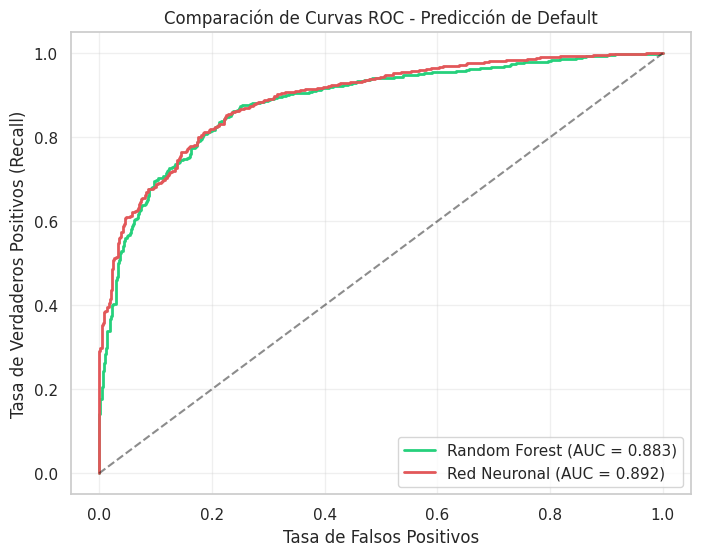

In [ ]:
# ------------------------------------------------------------------------------
# grafica curva roc comparativa
# ------------------------------------------------------------------------------

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_proba_nn)

plt.figure(figsize=(8, 6))

# ------------------------------------------------------------------------------
# curva de random forest
plt.plot(
    fpr_rf, 
    tpr_rf, 
    label=f'Random Forest (AUC = {auc_rf:.3f})', 
    color=_color_tecmi_light, 
    linewidth=2)

# ------------------------------------------------------------------------------
# curva de red neuronal
plt.plot(
    fpr_nn, 
    tpr_nn, 
    label=f'Red Neuronal (AUC = {auc_nn:.3f})', 
    color=_Red_, 
    linewidth=2)

# linea de ref
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

# ------------------------------------------------------------------------------
# layout y leyendas
plt.title('Comparación de Curvas ROC - Predicción de Default')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos (Recall)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## 🎏 Análisis de diferencias en los modelos

Cabe recordar que nuestro dataset tabular se adecua mejor a los algoritmos del modelo Random Forest, pues este utiliza menos recursos y menos tiempo para terminar sus tareas, mostrando un desempeño igual o superior al de la Red Neuronal Simple.

Definitivamente el modelo Random Forest tiene una ventaja nativa con el dataset tabular entendiendo mejor las características de este, lo que le permite lidiar de mejor manera con los valores atípicos y administrar el desbalance presentado en el caso de Novacredit en la variable objetivo. 
En cambio, en la Red Neuronal, al implementarse en una sola capa, actúa como una Regresión Logística mejorada, pues logra separar las clases, pero le cuesta capturar más detalles no lineales sin una arquitectura más elaborada.

Dadas las pruebas realizadas se concluye que la Red Neuronal genera predicciones exactas, pero funciona como una caja negra de información pues sufre de poca explicabilidad para poder entender que variables motivan el rechazo o aprobación de un cliente. Por otra parte, el Random Forest, proporciona un análisis directo de variables importantes, permitiendo al equipo de NovaCredit redactar políticas exactas de acuerdo al tipo o grupo de clientes.

#### 🎖️ Decisión final

Se selecciona el modelo **Random Forest** como el modelo definitivo en el caso de Novacredit para pasar a la fase de producción, priorizando el balance entre **precisión predictiva** y **explicabilidad**.